In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
dataframe= pd.read_csv("Zomato data .csv")

In [71]:
dataframe.shape

(148, 7)

In [72]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [73]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [74]:
pd.isnull(dataframe).sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [75]:
dataframe.duplicated().sum()

np.int64(0)

In [82]:
def handlrate(value):
    value=str(value).split ('/')
    value =value[0];
    return float(value)
    
df['rate'] = df['rate'].apply(handlrate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


# Data Visulization

Text(0.5, 0, 'type of resturant')

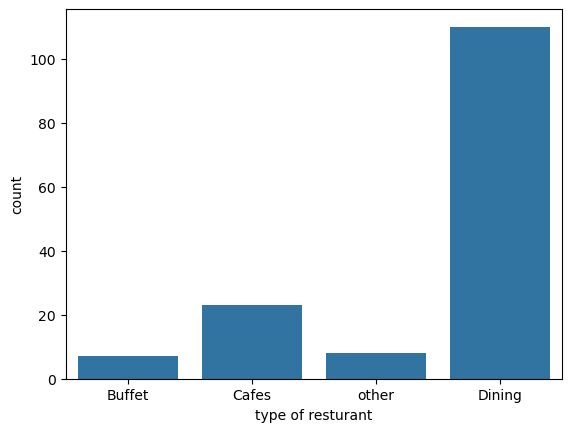

In [83]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel('type of resturant')             

Conclusion : Majority of Resturant falls in Dinning category

Text(0, 0.5, 'votes')

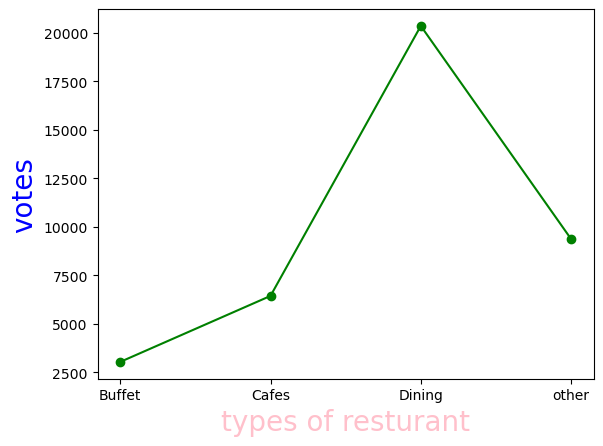

In [84]:
Group_data=dataframe.groupby('listed_in(type)')['votes'].sum()
result= pd.DataFrame({'votes': Group_data})
plt.plot(result, c="green", marker="o")
plt.xlabel("types of resturant",c= "pink", size=20)
plt.ylabel("votes", c="blue",size= 20)

Conclusion : Dinning Resturant Had result in Maximum Votes

In [81]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [92]:
dataframe['rate_clean'] = dataframe['rate'].astype(str).str.split('/').str[0]
dataframe['rate_clean'] = pd.to_numeric(dataframe['rate_clean'], errors='coerce')
dataframe = dataframe.dropna(subset=['rate_clean'])

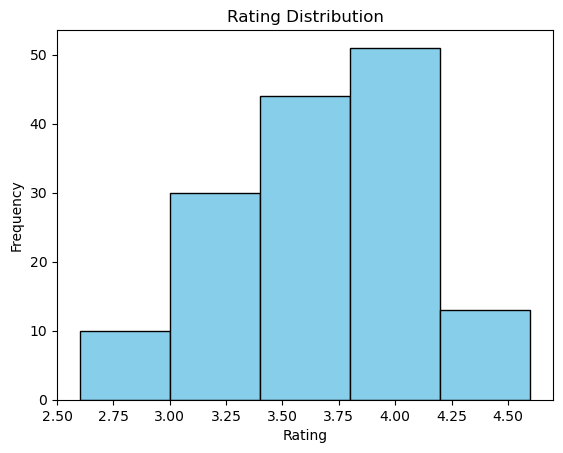

In [96]:
plt.hist(dataframe['rate_clean'], bins=5, color="skyblue", edgecolor="black")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Conclusion: the majority resturant recieved 3.5 to 4

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

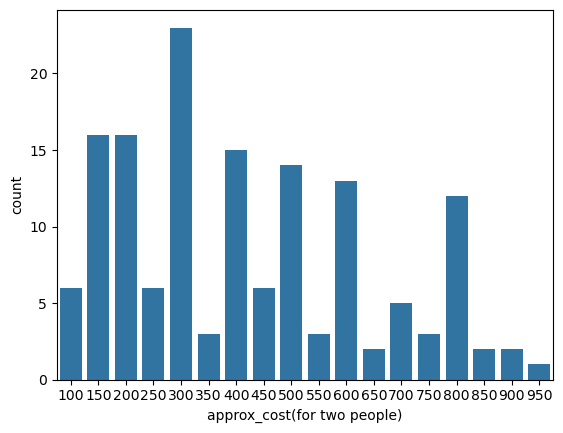

In [98]:
couple_data= dataframe["approx_cost(for two people)"]
sns.countplot(x=couple_data)

Conclusion: the majority couple preffer resturant with an approximate cost  of 300

<Axes: xlabel='online_order', ylabel='rate'>

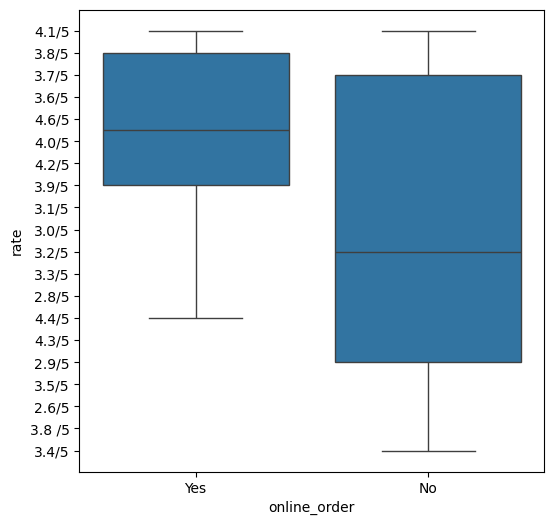

In [125]:
plt.figure(figsize=(6,6))
sns.boxplot(x="online_order", y="rate", data=dataframe)

Conclusion: Offline order has  less rating in order to Online order

In [135]:
dataframe.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)', 'rate_clean'],
      dtype='object')

## Thank you